# 13 — Astra vision + GeoAI: explain a change map

[Launch in JupyterLite](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=13_astra_vision_change.ipynb)

Build paired synthetic scenes, derive a change mask, evaluate it against known truth, and package a labeled comparison image for Astra. **Time:** about 25 minutes. **Prerequisites:** arrays and lab 03.

**Runtime:** browser Python for the analysis; hosted GeoLibre for maps; optional CPython runner for Astra. The default run makes no model calls. The first run needs network access for packages, GeoLibre and interactive Plotly scripts. Static plots and local analysis do not depend on data APIs.

**Learning cycle:** predict → run → compare views → explain → test a different assumption.

## See the connections

![Astra vision: compare, measure, challenge: Images: Aligned before and after teaching chips; GeoAI pattern: Threshold change and evaluate known truth; Astra: Read labeled images with numeric evidence; Check: Appearance alone cannot establish cause](assets/13_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage(["numpy", "pandas", "matplotlib", "scipy", "pillow"])
    import micropip
    await micropip.install(["geolibre==3.0.0", "plotly==6.5.0"])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from geolibre_lite import LiteMap as Map
from cognition import style_plots, COLORS, save_json
from astra_lab import make_request, response_text
style_plots()

## 1. A controlled scene makes mistakes measurable

These are **synthetic RGB chips**, not satellite imagery. One rectangle changes color, a bright patch imitates cloud, and random noise perturbs the second image. Both images share a 64 × 64 local grid with 20 m cells. Row zero is south. The anchored coordinates are illustrative, not a surveyed raster geotransform.

In [2]:
from cognition import grid_features, figure_data_url
rng = np.random.default_rng(42)
n = 64
yy, xx = np.mgrid[:n,:n]
before = np.empty((n,n,3), dtype=float)
before[:] = [.18,.48,.25]
before[:,28:34] = [.12,.25,.52]
before += rng.normal(0,.025,before.shape)
truth = (xx>=40) & (xx<54) & (yy>=12) & (yy<30)
cloud = (xx-16)**2 + (yy-45)**2 < 8**2
after = before.copy()
after[truth] = [.65,.42,.27]
after[cloud] = [.92,.92,.92]
after += rng.normal(0,.02,after.shape)
before, after = np.clip(before,0,1), np.clip(after,0,1)
valid = ~cloud  # oracle mask known because we generated the fixture
distance = np.linalg.norm(after-before, axis=2)
threshold = .22
predicted = (distance > threshold) & valid
tp = int((predicted & truth & valid).sum())
fp = int((predicted & ~truth & valid).sum())
fn = int((~predicted & truth & valid).sum())
tn = int((~predicted & ~truth & valid).sum())
iou = tp/(tp+fp+fn) if tp+fp+fn else 1.0
print("Valid pixels:", int(valid.sum()), "IoU:", round(iou,3))

Valid pixels: 3903 IoU: 1.0


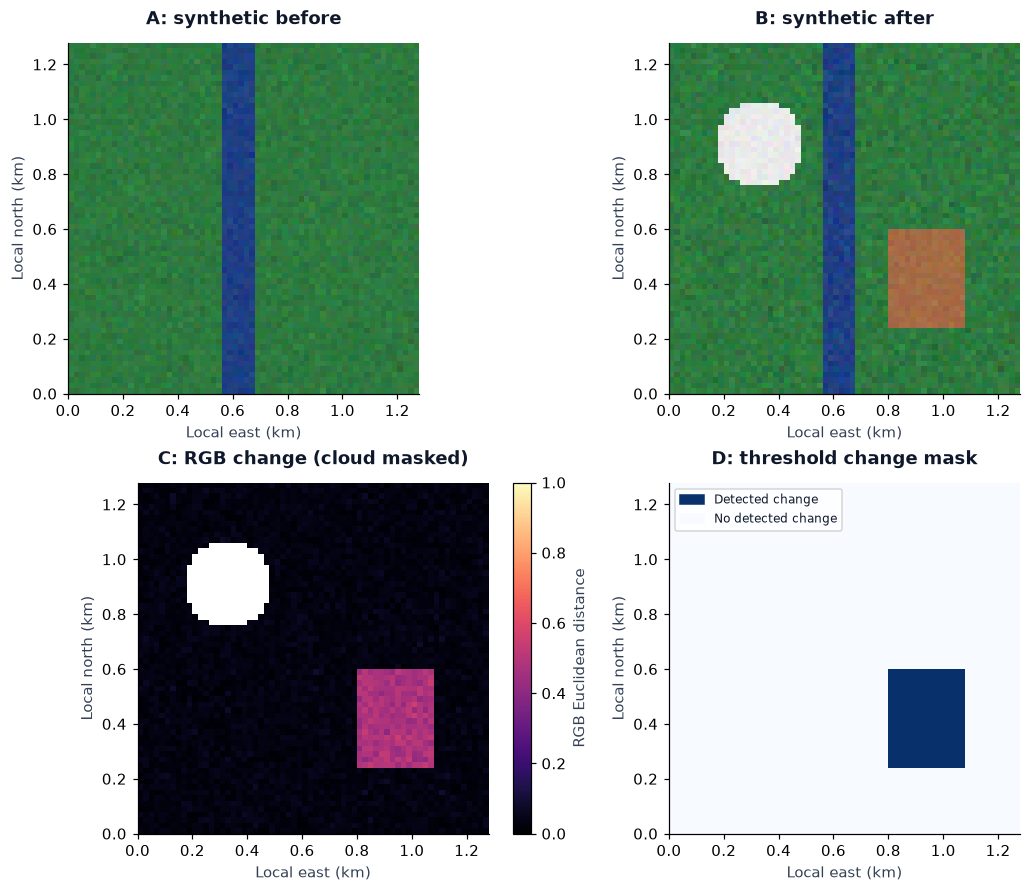

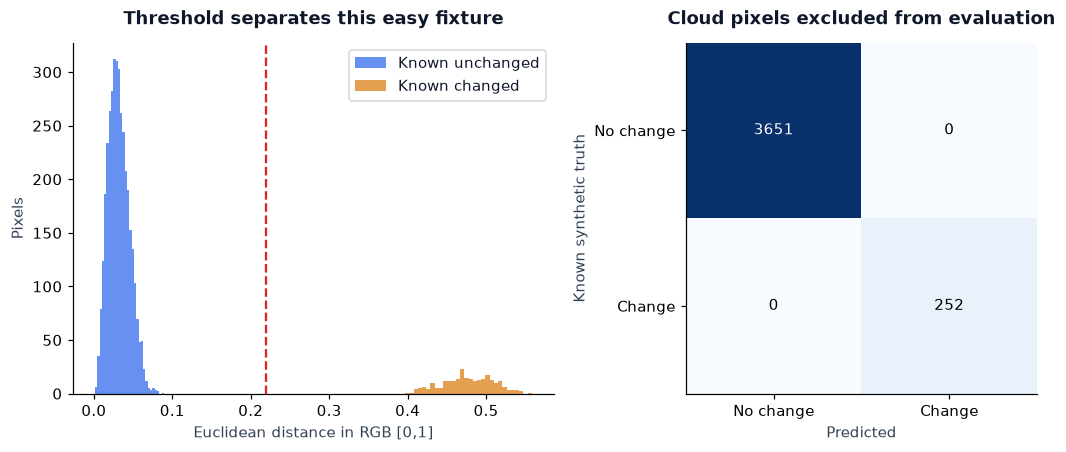

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
axes = axes.ravel()
extent = (0,1.28,0,1.28)
axes[0].imshow(before, origin="lower", extent=extent)
axes[1].imshow(after, origin="lower", extent=extent)
change_colors = axes[2].imshow(np.ma.masked_where(~valid,distance), origin="lower", extent=extent, cmap="magma", vmin=0,vmax=1)
axes[3].imshow(predicted, origin="lower", extent=extent, cmap="Blues", vmin=0,vmax=1)
for ax,title in zip(axes,["A: synthetic before","B: synthetic after","C: RGB change (cloud masked)","D: threshold change mask"]):
    ax.set(title=title,xlabel="Local east (km)",ylabel="Local north (km)")
fig.colorbar(change_colors,ax=axes[2],label="RGB Euclidean distance")
from matplotlib.patches import Patch
axes[3].legend(handles=[Patch(color="#08306b",label="Detected change"),Patch(color="#f7fbff",label="No detected change")],loc="upper left",fontsize=8)
image_evidence = figure_data_url(fig)
plt.show()
fig, axes = plt.subplots(1,2,figsize=(10,4),layout="constrained")
axes[0].hist(distance[valid & ~truth], bins=30, alpha=.7, label="Known unchanged")
axes[0].hist(distance[valid & truth], bins=30, alpha=.7, label="Known changed")
axes[0].axvline(threshold,color="#dc2626",ls="--")
axes[0].set(xlabel="Euclidean distance in RGB [0,1]",ylabel="Pixels",title="Threshold separates this easy fixture")
axes[0].legend()
matrix = np.array([[tn,fp],[fn,tp]])
axes[1].imshow(matrix,cmap="Blues")
axes[1].set_xticks([0,1],["No change","Change"])
axes[1].set_yticks([0,1],["No change","Change"])
axes[1].set(xlabel="Predicted",ylabel="Known synthetic truth",title="Cloud pixels excluded from evaluation")
for r in range(2):
    for c in range(2):
        axes[1].text(c,r,str(matrix[r,c]),ha="center",va="center",color="white" if matrix[r,c]>matrix.max()/2 else "black")
plt.show()

## 2. Map the same cells and their area

Each cell covers exactly 400 m² in the **synthetic local grid**. Count cells there before applying the approximate longitude/latitude display transform. Do not calculate area in square degrees.

In [4]:
change_fc = grid_features(predicted.astype(float), field="changed", cell_m=20)
change_fc['features'] = [f for f in change_fc['features'] if f['properties']['changed']==1]
change_map = Map(center=(-122.293,37.906),zoom=14,height="480px")
if change_fc['features']:
    change_map.add_geojson(change_fc, name="Synthetic detected change",fillColor="#d97706",strokeWidth=0)
display(change_map)
area_m2 = int(predicted.sum()) * 20**2
print("Synthetic detected area (m²):",area_m2)
save_json("exports/synthetic_change.geojson",change_fc)

Synthetic detected area (m²): 100800


'exports\\synthetic_change.geojson'

## 3. Give Astra an image and computed evidence

The vision request asks for observations and missing checks, not invented spectral measurements or causes. The numeric evidence carries pixel size, masks, confusion counts and IoU. An image-only answer could mistake the bright patch for meaningful land change.

In [5]:
evidence = {"evidence_id":"change_metrics", "source":"synthetic RGB fixture, seed 42",
            "pixel_size_m":20, "orientation":"north up; row 0 south in arrays", "threshold":threshold,
            "valid_pixels":int(valid.sum()), "masked_cloud_pixels":int(cloud.sum()),
            "tp":tp,"fp":fp,"fn":fn,"tn":tn,"iou":iou,"detected_area_m2":area_m2}
request = make_request("Compare panels A-D. Cite change_metrics. Distinguish observed color changes from possible causes. Explain why this easy synthetic result does not validate a real EO model.",
                       evidence, images=[image_evidence])
save_json("exports/vision_change_request.json",request)
print("Request contains one labeled PNG and computed metrics; not sent.")

Request contains one labeled PNG and computed metrics; not sent.


## Optional: run this request with GPT-6 Astra

All calculations above run locally. The exported request has **not been sent** and any example plan is **hand-authored**, not a recorded model response. To obtain a live response:

1. Download the generated request from JupyterLite's file browser (right-click → Download).
2. In a full CPython terminal in this repository, set `OPENAI_API_KEY` in that terminal's environment. Never put the key in a notebook, output, or the static site.
3. Preview with `python scripts/run_astra.py PATH_TO_REQUEST.json`. Send deliberately with `--send --output astra_response.json`. This uses your API account and can incur charges.
4. Upload `astra_response.json` to the notebook folder, set the import path in the next cell, and rerun it. Inspect its evidence claims before using them.

For notebook 15, also download `accessibility_evidence.json` and pass `--evidence PATH_TO_EVIDENCE.json`. The runner only dispatches the one allowlisted local tool, with a bounded number of rounds.

The static JupyterLite site does not host this runner or proxy requests. Model access depends on your API project. Image reading is an aid to interpretation; geometry, distances and metrics come from code and explicit metadata.

In [6]:
RESPONSE_PATH = None
if RESPONSE_PATH:
    report = json.loads(response_text(json.loads(Path(RESPONSE_PATH).read_text())))
    display(report)
else:
    print("No model explanation generated. Use the evidence to write your own interpretation first.")

No model explanation generated. Use the evidence to write your own interpretation first.


## 4. Stress the explanation

Set `valid = np.ones_like(cloud)` and rerun from the mask calculation to see false positives from cloud. Raise the threshold and observe missed changes. Shift one image by one pixel to test registration error.

**Real-data handoff:** use STAC IDs, acquisition times, calibrated bands, a documented CRS/transform, cloud masks and independent labels. In full GeoAI, compare a trained change detector with this simple baseline; return its georeferenced predictions to GeoLibre. Astra can review that evidence, but an attractive explanation does not substitute for validation.

## Data & software citations

- Teaching fixtures: deterministic synthetic arrays and networks authored in this repository. Values, scenes, facilities and outcomes are invented; coordinates only anchor the display. No actual people, environmental measurements, or service areas are represented.
- [GeoLibre](https://geolibre.app/) and [GeoLibre map controls](https://geolibre.app/user-guide/map-controls/); `geolibre==3.0.0` project builders through `geolibre_lite.LiteMap`.
- [GeoAI](https://opengeoai.org/): full Python/GPU continuation for imagery models. These browser labs implement workflow patterns; they do not install or run `geoai-py`.
- [GPT-6 Astra model](https://developers.openai.com/api/docs/models/gpt-6-astra), [Structured Outputs](https://developers.openai.com/api/docs/guides/structured-outputs), [image inputs](https://developers.openai.com/api/docs/guides/images-vision), and [function calling](https://developers.openai.com/api/docs/guides/function-calling). API examples checked 2026-10-02.
- [Pyodide packages](https://pyodide.org/en/stable/usage/packages-in-pyodide.html), [Matplotlib](https://matplotlib.org/stable/), [Plotly Python](https://plotly.com/python/).
- GeoLibre basemap tiles retain their provider attribution, including [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) where applicable.

See `DATA_SOURCES.md` for the source register and runtime boundaries.